In [1]:
import sys
from pathlib import Path

try:
    ROOT = Path(globals()['__vsc_ipynb_file__']).resolve().parent.parent
except KeyError:
    ROOT = Path.cwd()
    for _ in range(4):
        if (ROOT / 'src').is_dir():
            break
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.experiments.mmused_text import DEFAULT_DATA_PATH, make_mmused_fallacy_loader

DATA_PATH = DEFAULT_DATA_PATH
FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

loader_afc = make_mmused_fallacy_loader("afc")

print(loader_afc.data.shape)
print(loader_afc.data.columns.tolist())

Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 16509.24it/s]

(1278, 8)
['dialogue_tokens', 'dialogue', 'dialogue_id', 'dialogue_paths', 'snippet_indexes', 'snippet', 'snippet_paths', 'fallacy']


In [2]:
loader_afd = make_mmused_fallacy_loader("afd")
print(loader_afd.data.shape)
print(loader_afd.data['label'].value_counts())


Building AFD data...: 100%|██████████| 35/35 [00:01<00:00, 24.45it/s]


(17118, 7)
label
0    15550
1     1568
Name: count, dtype: int64


In [3]:
# AFC label distribution
print(loader_afc.data['fallacy'].value_counts().sort_index())
print(f"\nTotal AFC samples: {len(loader_afc.data)}")
print(f"Unique dialogues: {loader_afc.data['dialogue_id'].nunique()}")


fallacy
0    800
1    191
2    149
3     56
4     46
5     36
Name: count, dtype: int64

Total AFC samples: 1278
Unique dialogues: 35


In [4]:
# Cell 1 - class weights for AFC
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
labels = loader_afc.data['fallacy'].values
weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
print(dict(zip(np.unique(labels), weights.round(4))))


{0: np.float64(0.2662), 1: np.float64(1.1152), 2: np.float64(1.4295), 3: np.float64(3.8036), 4: np.float64(4.6304), 5: np.float64(5.9167)}


In [5]:
print(loader_afd.data['label'].value_counts())

label
0    15550
1     1568
Name: count, dtype: int64


In [6]:
labels_afd = loader_afd.data['label'].values
weights_afd = compute_class_weight('balanced', classes=np.unique(labels_afd), y=labels_afd)
print(dict(zip(np.unique(labels_afd), weights_afd.round(4))))


{np.int64(0): np.float64(0.5504), np.int64(1): np.float64(5.4585)}


# Label distributions 

In [7]:
loader_afc.data.head()

,dialogue_tokens,dialogue,dialogue_id,dialogue_paths,snippet_indexes,snippet,snippet_paths,fallacy
0,"[[{'word': 'These', 'start': 712.29, 'end': 71...",These people depend upon all of us for the lit...,10_1984,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,[87],And there are other ways of squeezing this bud...,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,0
1,"[[{'word': 'In', 'start': 1189.873, 'end': 118...","In mine, I happen to believe in the people and...",10_1984,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,[149],And you let those people go with the guideline...,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,0
2,"[[{'word': 'And', 'start': 1158.827, 'end': 11...","And, incidentally, I might say that with regar...",10_1984,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,[146],"In mine, I happen to believe in the people and...",[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,1
3,"[[{'word': 'All', 'start': 1793.694, 'end': 17...",All history tells us that that's a mistake. Wh...,10_1984,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,[231],That's why faith in the United States is pure ...,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,0
4,"[[{'word': 'All', 'start': 1793.694, 'end': 17...",All history tells us that that's a mistake. Wh...,10_1984,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,[231],That's why faith in the United States is pure ...,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,0


In [8]:
loader_afd.data.head()

,context_paths,context,sentence,sentence_path,label,dialogue_id,filename
0,[],,I have a plan -- not a secret plan.,/mm_argfallacy/data/MMUSED-fallacy/audio_clips...,0,10_1984,1984_07Oct_1
1,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,I have a plan -- not a secret plan.,"As a matter of fact, it is the economic recove...",/mm_argfallacy/data/MMUSED-fallacy/audio_clips...,0,10_1984,1984_07Oct_1
2,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,I have a plan -- not a secret plan. As a matte...,"It is true that earlier, working with some ver...",/mm_argfallacy/data/MMUSED-fallacy/audio_clips...,0,10_1984,1984_07Oct_1
3,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,I have a plan -- not a secret plan. As a matte...,"Before even the election day, something that n...",/mm_argfallacy/data/MMUSED-fallacy/audio_clips...,0,10_1984,1984_07Oct_1
4,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,"As a matter of fact, it is the economic recove...","Under that, this year, we have seen a $21 bill...",/mm_argfallacy/data/MMUSED-fallacy/audio_clips...,0,10_1984,1984_07Oct_1


In [9]:
print(loader_afc.data.columns.tolist())
print(loader_afc.data.head())

['dialogue_tokens', 'dialogue', 'dialogue_id', 'dialogue_paths', 'snippet_indexes', 'snippet', 'snippet_paths', 'fallacy']
                                     dialogue_tokens  \
0  [[{'word': 'These', 'start': 712.29, 'end': 71...   
1  [[{'word': 'In', 'start': 1189.873, 'end': 118...   
2  [[{'word': 'And', 'start': 1158.827, 'end': 11...   
3  [[{'word': 'All', 'start': 1793.694, 'end': 17...   
4  [[{'word': 'All', 'start': 1793.694, 'end': 17...   

                                            dialogue dialogue_id  \
0  These people depend upon all of us for the lit...     10_1984   
1  In mine, I happen to believe in the people and...     10_1984   
2  And, incidentally, I might say that with regar...     10_1984   
3  All history tells us that that's a mistake. Wh...     10_1984   
4  All history tells us that that's a mistake. Wh...     10_1984   

                                      dialogue_paths snippet_indexes  \
0  [/mm_argfallacy/data/MMUSED-fallacy/audio_clip...       

/tmp/ipykernel_95370/336424975.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=afc_df, x='Fallacy', y='Count', palette='viridis')


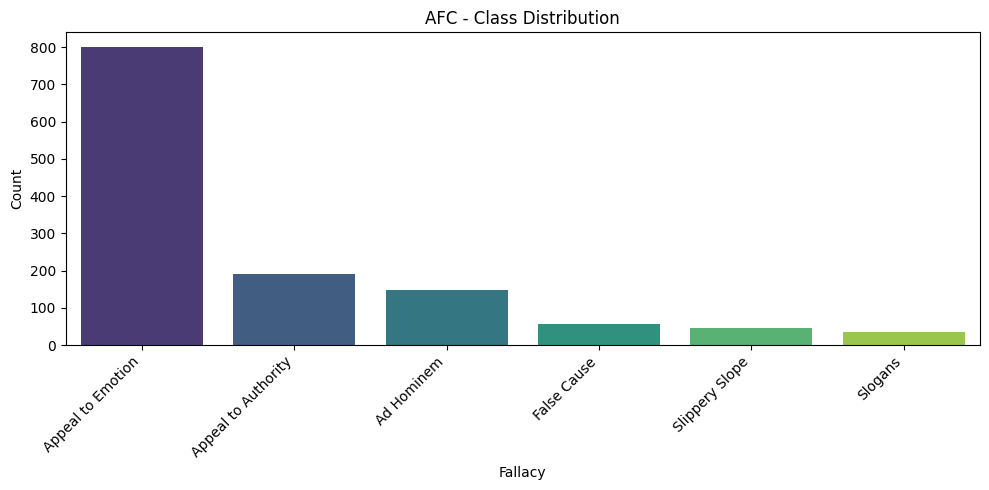

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

label_names = {
    0: 'Appeal to Emotion',
    1: 'Appeal to Authority',
    2: 'Ad Hominem',
    3: 'False Cause',
    4: 'Slippery Slope',
    5: 'Slogans'
}


# AFC distribution
afc_counts = loader_afc.data['fallacy'].value_counts().sort_index()
afc_df = pd.DataFrame({
    'Fallacy': [label_names[i] for i in afc_counts.index],
    'Count': afc_counts.values
})

plt.figure(figsize=(10, 5))
sns.barplot(data=afc_df, x='Fallacy', y='Count', palette='viridis')
plt.title('AFC - Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'afc_distribution.png')
plt.show()



/tmp/ipykernel_95370/2972530853.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=afd_df, x='Label', y='Count', palette='viridis')


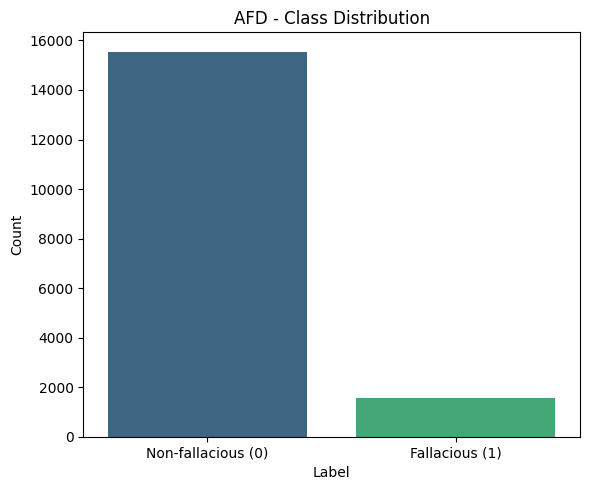

In [11]:
 #AFD distribution
afd_counts = loader_afd.data['label'].value_counts().sort_index()
afd_df = pd.DataFrame({
    'Label': ['Non-fallacious (0)', 'Fallacious (1)'],
    'Count': afd_counts.values
})

plt.figure(figsize=(6, 5))
sns.barplot(data=afd_df, x='Label', y='Count', palette='viridis')
plt.title('AFD - Class Distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / 'afd_distribution.png')
plt.show()

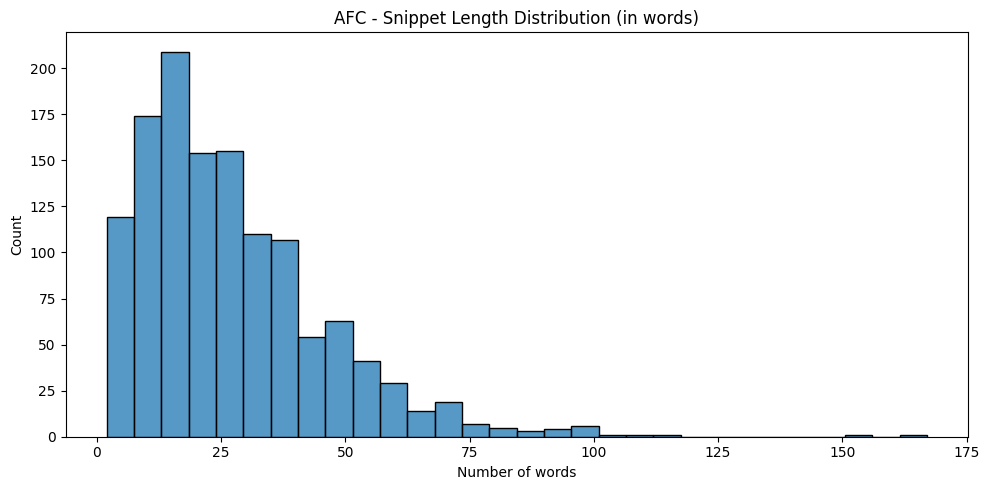

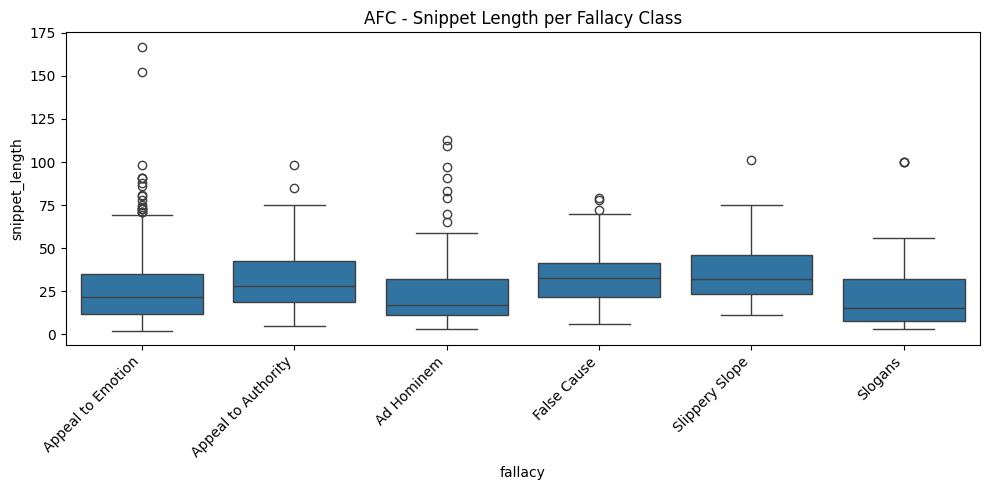

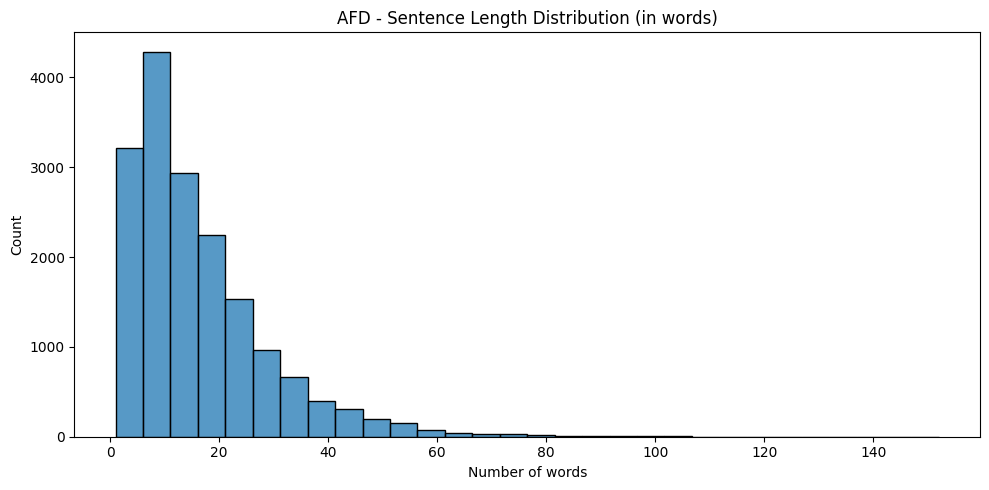

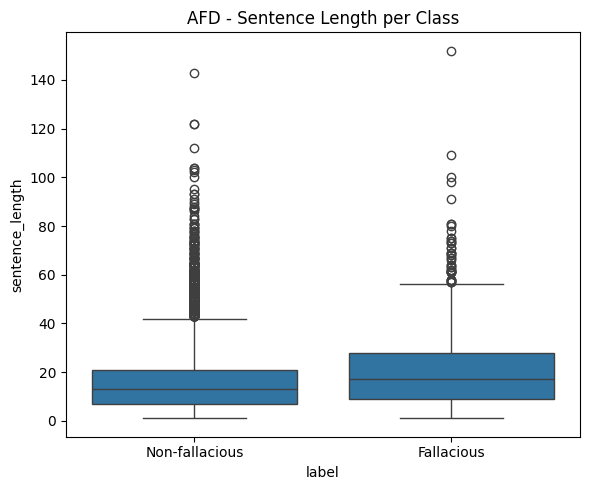

In [12]:
# AFC - snippet length in words
loader_afc.data['snippet_length'] = loader_afc.data['snippet'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(data=loader_afc.data, x='snippet_length', bins=30)
plt.title('AFC - Snippet Length Distribution (in words)')
plt.xlabel('Number of words')
plt.tight_layout()
plt.savefig(FIG_DIR / 'afc_length.png')
plt.show()

# AFC - length per class
plt.figure(figsize=(10, 5))
sns.boxplot(data=loader_afc.data, x='fallacy', y='snippet_length')
plt.xticks(ticks=range(6), labels=list(label_names.values()), rotation=45, ha='right')
plt.title('AFC - Snippet Length per Fallacy Class')
plt.tight_layout()
plt.savefig(FIG_DIR / 'afc_length_per_class.png')
plt.show()

# AFD - sentence length in words
loader_afd.data['sentence_length'] = loader_afd.data['sentence'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(data=loader_afd.data, x='sentence_length', bins=30)
plt.title('AFD - Sentence Length Distribution (in words)')
plt.xlabel('Number of words')
plt.tight_layout()
plt.savefig(FIG_DIR / 'afd_length.png')
plt.show()

# AFD - length per class
plt.figure(figsize=(6, 5))
sns.boxplot(data=loader_afd.data, x='label', y='sentence_length')
plt.xticks(ticks=[0, 1], labels=['Non-fallacious', 'Fallacious'])
plt.title('AFD - Sentence Length per Class')
plt.tight_layout()
plt.savefig(FIG_DIR / 'afd_length_per_class.png')
plt.show()

In [13]:
# AFC - 2 examples per class
print("=== AFC - Examples per Fallacy Class ===\n")
for label_id, label_name in label_names.items():
    examples = loader_afc.data[loader_afc.data['fallacy'] == label_id]['snippet'].head(2)
    print(f"--- {label_name} ---")
    for i, ex in enumerate(examples):
        print(f"  {i+1}. {ex[:200]}")
    print()

# AFD - examples fallacious vs non-fallacious
print("=== AFD - Fallacious vs Non-fallacious ===\n")
print("--- Non-fallacious (0) ---")
for i, ex in enumerate(loader_afd.data[loader_afd.data['label'] == 0]['sentence'].head(3)):
    print(f"  {i+1}. {ex[:200]}")

print("\n--- Fallacious (1) ---")
for i, ex in enumerate(loader_afd.data[loader_afd.data['label'] == 1]['sentence'].head(3)):
    print(f"  {i+1}. {ex[:200]}")

=== AFC - Examples per Fallacy Class ===

--- Appeal to Emotion ---
  1. And there are other ways of squeezing this budget without constantly picking on our senior citizens and the most vulnerable in American life.
  2. And you let those people go with the guidelines of overall policy, not looking over their shoulder and nitpicking the manner in which they go at the job.

--- Appeal to Authority ---
  1. In mine, I happen to believe in the people and believe that the people are supposed to be dominant in our society -- that they, not government, are to have control of their own affairs to the greatest
  2. And when people vote, I think you're going to see a very strong verdict by the American people that they favor the approach that I'm talking about.

--- Ad Hominem ---
  1. Well, the other day, Vice President Bush disclosed his tax returns to the American people. He's one of the wealthiest Americans, and he's our Vice President. In 1981 I think he paid about 40 percent i
  2. America

In [14]:
# 4. Dialogue context
print("=== Dialogue Context Analysis ===\n")

# Sentences per dialogue
sentences_per_dialogue = loader_afd.data.groupby('dialogue_id').size()
print(f"Sentences per dialogue:")
print(f"  Mean:   {sentences_per_dialogue.mean():.1f}")
print(f"  Median: {sentences_per_dialogue.median():.1f}")
print(f"  Max:    {sentences_per_dialogue.max()}")
print(f"  Min:    {sentences_per_dialogue.min()}")

# Fallacies per dialogue
fallacies_per_dialogue = loader_afd.data[loader_afd.data['label'] == 1].groupby('dialogue_id').size()
print(f"\nFallacies per dialogue:")
print(f"  Mean:   {fallacies_per_dialogue.mean():.1f}")
print(f"  Median: {fallacies_per_dialogue.median():.1f}")
print(f"  Max:    {fallacies_per_dialogue.max()}")
print(f"  Min:    {fallacies_per_dialogue.min()}")

# 5. Class imbalance summary table
print("\n=== Class Imbalance Summary ===\n")
from sklearn.utils.class_weight import compute_class_weight

# AFC
afc_labels = loader_afc.data['fallacy'].values
afc_classes = np.unique(afc_labels)
afc_weights = compute_class_weight(class_weight='balanced', classes=afc_classes, y=afc_labels)
total = len(afc_labels)

summary = []
for i, (cls, w) in enumerate(zip(afc_classes, afc_weights)):
    count = (afc_labels == cls).sum()
    summary.append({
        'Class': label_names[cls],
        'Count': count,
        'Percentage': f"{100*count/total:.1f}%",
        'Weight': f"{w:.2f}"
    })

summary_df = pd.DataFrame(summary)
print("AFC:")
print(summary_df.to_string(index=False))

# AFD
print("\nAFD:")
afd_labels = loader_afd.data['label'].values
afd_classes = np.unique(afd_labels)
afd_weights = compute_class_weight(class_weight='balanced', classes=afd_classes, y=afd_labels)
total_afd = len(afd_labels)

for cls, w in zip(afd_classes, afd_weights):
    count = (afd_labels == cls).sum()
    print(f"  {'Fallacious' if cls==1 else 'Non-fallacious'}: {count} ({100*count/total_afd:.1f}%) — weight: {w:.2f}")

# Save weights for later use
import json
weights_dict = {
    'afc': {int(cls): float(w) for cls, w in zip(afc_classes, afc_weights)},
    'afd': {int(cls): float(w) for cls, w in zip(afd_classes, afd_weights)}
}
with open(ROOT / 'data' / 'class_weights.json', 'w') as f:
    json.dump(weights_dict, f, indent=2)
print(f"\nWeights saved to {ROOT / 'data' / 'class_weights.json'}")

=== Dialogue Context Analysis ===

Sentences per dialogue:
  Mean:   489.1
  Median: 405.0
  Max:    959
  Min:    36

Fallacies per dialogue:
  Mean:   44.8
  Median: 43.0
  Max:    98
  Min:    1

=== Class Imbalance Summary ===

AFC:
              Class  Count Percentage Weight
  Appeal to Emotion    800      62.6%   0.27
Appeal to Authority    191      14.9%   1.12
         Ad Hominem    149      11.7%   1.43
        False Cause     56       4.4%   3.80
     Slippery Slope     46       3.6%   4.63
            Slogans     36       2.8%   5.92

AFD:
  Non-fallacious: 15550 (90.8%) — weight: 0.55
  Fallacious: 1568 (9.2%) — weight: 5.46

Weights saved to /mm_argfallacy/data/class_weights.json


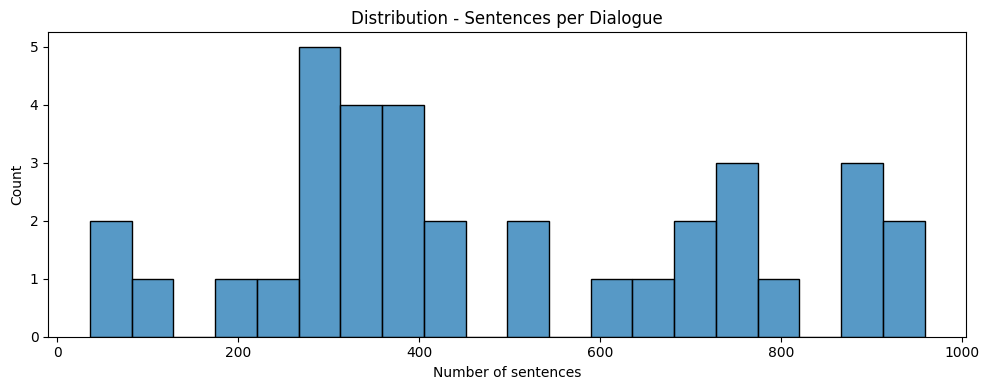

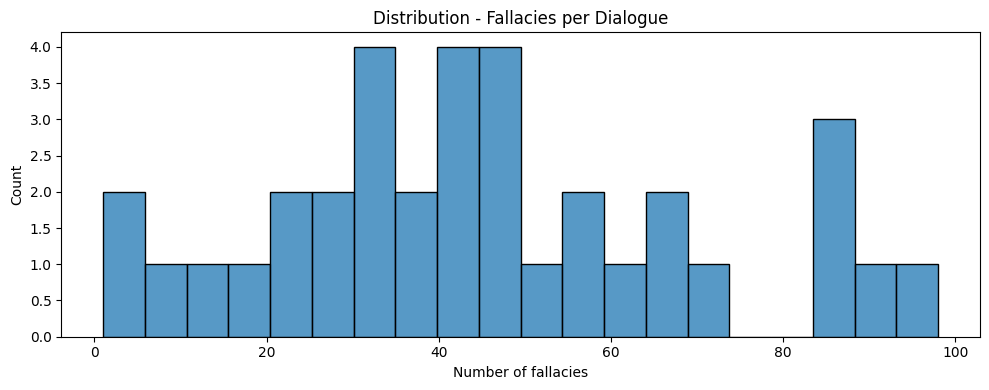

In [15]:
# Distribution du nombre de phrases par dialogue
plt.figure(figsize=(10, 4))
sns.histplot(sentences_per_dialogue, bins=20)
plt.title('Distribution - Sentences per Dialogue')
plt.xlabel('Number of sentences')
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentences_per_dialogue.png')
plt.show()

# Distribution des fallacies par dialogue
plt.figure(figsize=(10, 4))
sns.histplot(fallacies_per_dialogue, bins=20)
plt.title('Distribution - Fallacies per Dialogue')
plt.xlabel('Number of fallacies')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fallacies_per_dialogue.png')
plt.show()

In [16]:
plt.figure(figsize=(16, 6))

# Couleurs selon le taux
colors = ['#e74c3c' if v > fallacy_rate.mean() else '#3498db' for v in fallacy_rate.values]

bars = plt.bar(range(len(fallacy_rate)), fallacy_rate.values, color=colors, edgecolor='white', linewidth=0.5)

# Ligne moyenne
plt.axhline(y=fallacy_rate.mean(), color='#2c3e50', linestyle='--', linewidth=1.5, 
            label=f'Mean: {fallacy_rate.mean():.1f}%')

# Styling
plt.title('Fallacy Rate per Dialogue', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Dialogue ID', fontsize=12)
plt.ylabel('% Fallacious Sentences', fontsize=12)
plt.xticks(range(len(fallacy_rate)), fallacy_rate.index, rotation=90, fontsize=6)
plt.legend(fontsize=11)

# Annotation max
max_idx = fallacy_rate.values.argmax()
plt.annotate(f'Max: {fallacy_rate.max():.1f}%', 
             xy=(max_idx, fallacy_rate.max()),
             xytext=(max_idx + 2, fallacy_rate.max() + 1),
             fontsize=9, color='#e74c3c',
             arrowprops=dict(arrowstyle='->', color='#e74c3c'))

# Background
plt.gca().set_facecolor('#f8f9fa')
plt.gcf().set_facecolor('white')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fallacy_rate_per_dialogue.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'fallacy_rate' is not defined

<Figure size 1600x600 with 0 Axes>

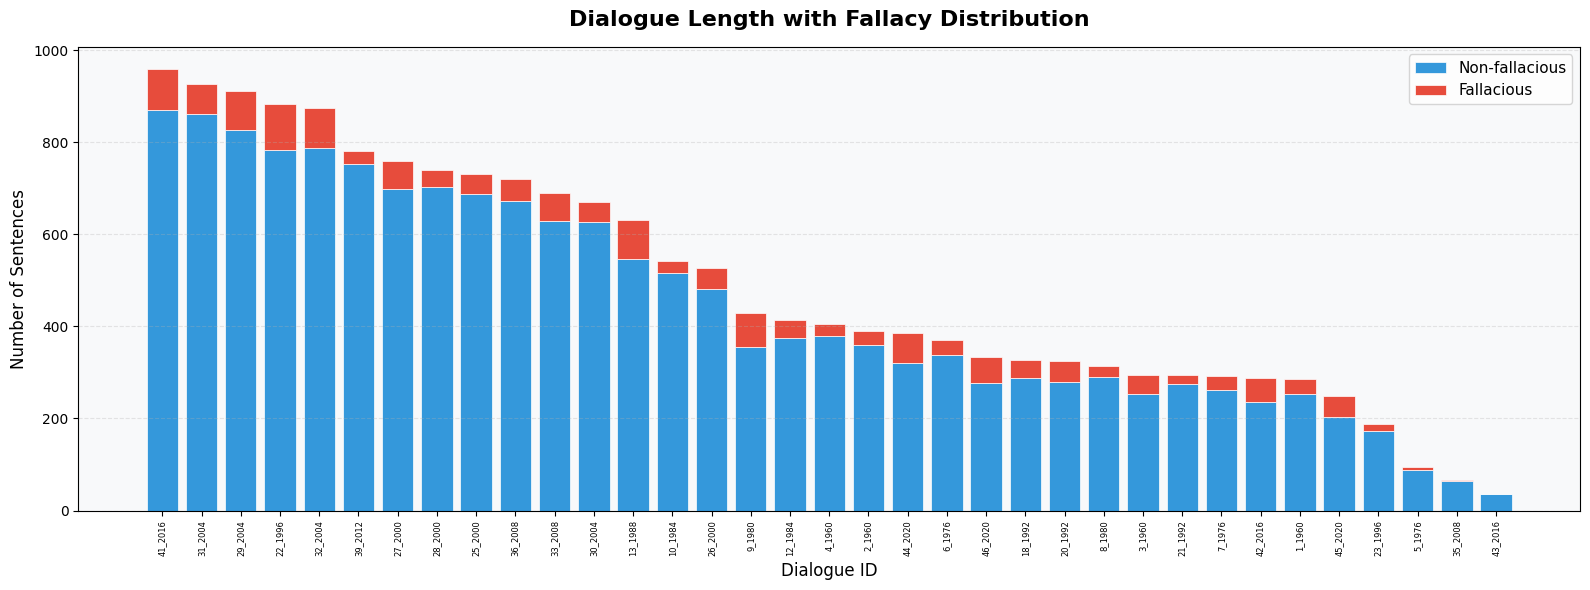

In [17]:
# Stacked bar chart - total sentences vs fallacious
total_per_dialogue = loader_afd.data.groupby('dialogue_id').size().sort_values(ascending=False)
fallacies_count = loader_afd.data[loader_afd.data['label'] == 1].groupby('dialogue_id').size().reindex(total_per_dialogue.index).fillna(0)
non_fallacies_count = total_per_dialogue - fallacies_count

fig, ax = plt.subplots(figsize=(16, 6))

# Stacked bars
ax.bar(range(len(total_per_dialogue)), non_fallacies_count.values, 
       color='#3498db', label='Non-fallacious', edgecolor='white', linewidth=0.5)
ax.bar(range(len(total_per_dialogue)), fallacies_count.values, 
       bottom=non_fallacies_count.values,
       color='#e74c3c', label='Fallacious', edgecolor='white', linewidth=0.5)

# Styling
ax.set_title('Dialogue Length with Fallacy Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Dialogue ID', fontsize=12)
ax.set_ylabel('Number of Sentences', fontsize=12)
ax.set_xticks(range(len(total_per_dialogue)))
ax.set_xticklabels(total_per_dialogue.index, rotation=90, fontsize=6)
ax.legend(fontsize=11)
ax.set_facecolor('#f8f9fa')
fig.set_facecolor('white')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(FIG_DIR / 'stacked_dialogue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_95370/3804379639.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loader_afc.data, x='fallacy', y='snippet_length',
/tmp/ipykernel_95370/3804379639.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=loader_afc.data, x='fallacy', y='snippet_length',


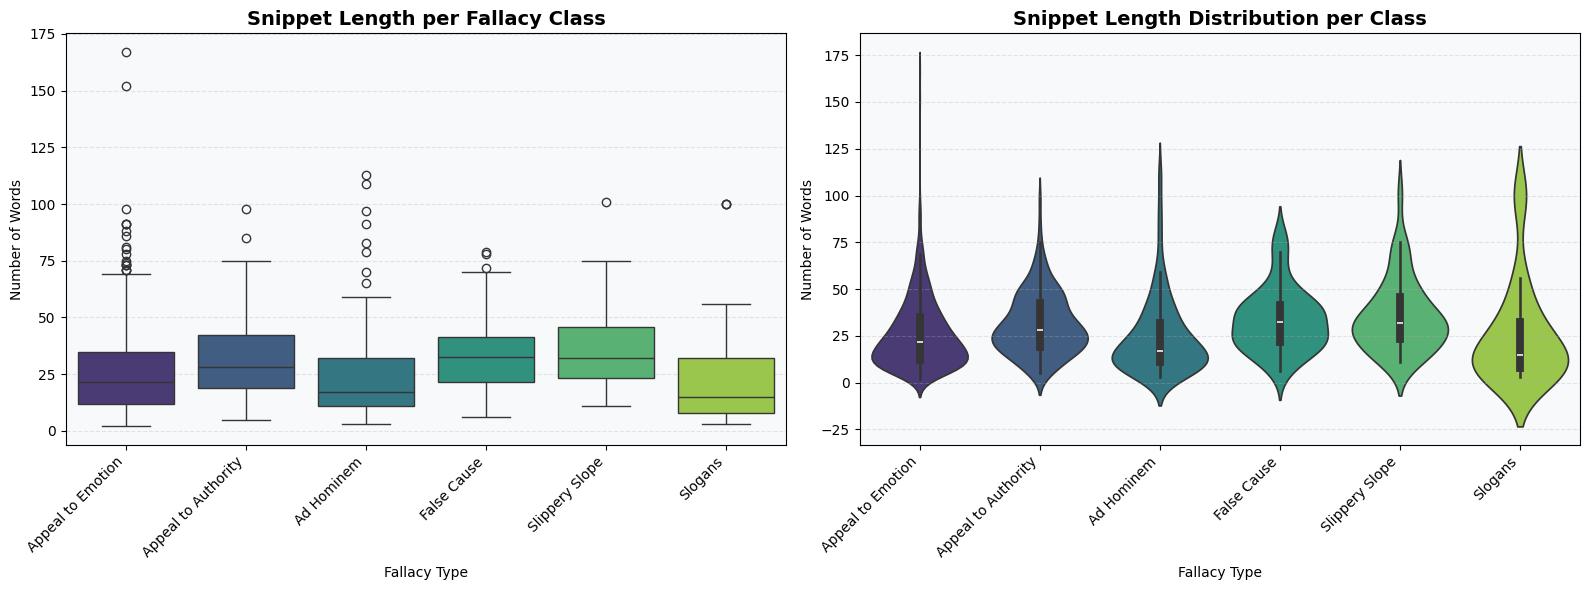

In [18]:
# Longueur des snippets par classe
loader_afc.data['snippet_length'] = loader_afc.data['snippet'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(data=loader_afc.data, x='fallacy', y='snippet_length', 
            palette='viridis', ax=axes[0])
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(list(label_names.values()), rotation=45, ha='right')
axes[0].set_title('Snippet Length per Fallacy Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fallacy Type')
axes[0].set_ylabel('Number of Words')
axes[0].set_facecolor('#f8f9fa')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Violinplot
sns.violinplot(data=loader_afc.data, x='fallacy', y='snippet_length',
               palette='viridis', ax=axes[1])
axes[1].set_xticks(range(6))
axes[1].set_xticklabels(list(label_names.values()), rotation=45, ha='right')
axes[1].set_title('Snippet Length Distribution per Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fallacy Type')
axes[1].set_ylabel('Number of Words')
axes[1].set_facecolor('#f8f9fa')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

fig.set_facecolor('white')
plt.tight_layout()
plt.savefig(FIG_DIR / 'snippet_length_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

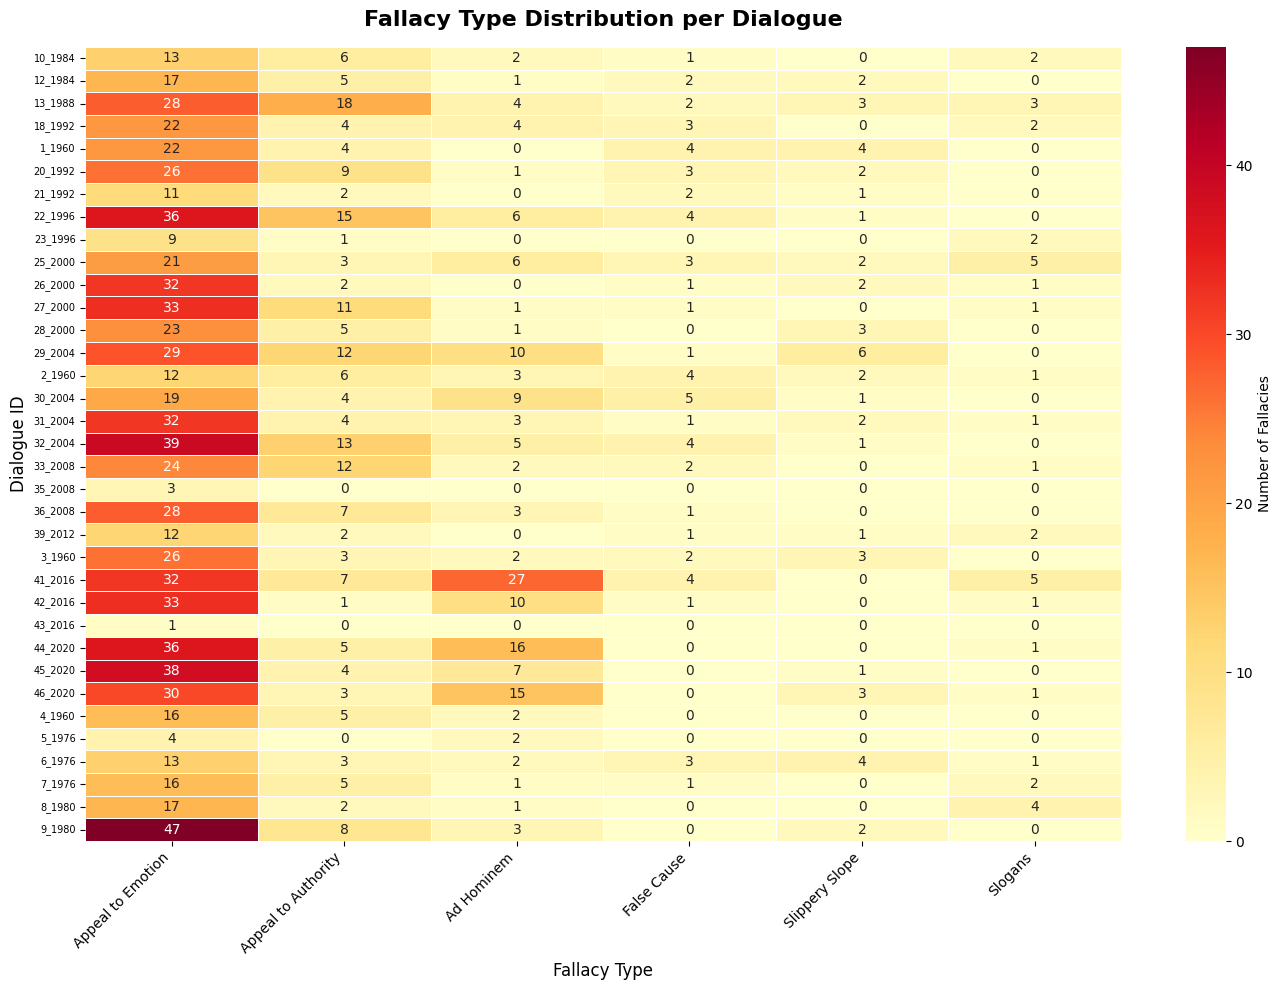

In [19]:
# Heatmap fallacy type per dialogue
heatmap_data = loader_afc.data.groupby(['dialogue_id', 'fallacy']).size().unstack(fill_value=0)
heatmap_data.columns = [label_names[c] for c in heatmap_data.columns]

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, 
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            annot=True,
            fmt='d',
            cbar_kws={'label': 'Number of Fallacies'})

plt.title('Fallacy Type Distribution per Dialogue', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Fallacy Type', fontsize=12)
plt.ylabel('Dialogue ID', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / 'heatmap_fallacy_per_dialogue.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
loader_afc.data['snippet'].str.split().str.len().describe()


count    1278.000000
mean       27.184664
std        18.902926
min         2.000000
25%        13.000000
50%        23.000000
75%        37.000000
max       167.000000
Name: snippet, dtype: float64

# AFD 

In [1]:
# AFD — setup
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    ROOT = Path(globals()['__vsc_ipynb_file__']).resolve().parent.parent
except KeyError:
    ROOT = Path.cwd()
    for _ in range(4):
        if (ROOT / 'src').is_dir():
            break
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from mamkit.data.datasets import MMUSEDFallacy, InputMode

DATA = ROOT / "data"
sns.set_context("notebook")

In [2]:
# Build AFD dataframe
afd = MMUSEDFallacy(
    task_name="afd",
    input_mode=InputMode.TEXT_ONLY,
    base_data_path=DATA,
)
df = afd.data.copy()

print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()

Building AFD data...: 100%|██████████| 35/35 [00:01<00:00, 25.36it/s]


shape: (17118, 7)
columns: ['context_paths', 'context', 'sentence', 'sentence_path', 'label', 'dialogue_id', 'filename']


,context_paths,context,sentence,sentence_path,label,dialogue_id,filename
0,[],,I have a plan -- not a secret plan.,/mm_argfallacy/data/MMUSED-fallacy/audio_clips...,0,10_1984,1984_07Oct_1
1,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,I have a plan -- not a secret plan.,"As a matter of fact, it is the economic recove...",/mm_argfallacy/data/MMUSED-fallacy/audio_clips...,0,10_1984,1984_07Oct_1
2,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,I have a plan -- not a secret plan. As a matte...,"It is true that earlier, working with some ver...",/mm_argfallacy/data/MMUSED-fallacy/audio_clips...,0,10_1984,1984_07Oct_1
3,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,I have a plan -- not a secret plan. As a matte...,"Before even the election day, something that n...",/mm_argfallacy/data/MMUSED-fallacy/audio_clips...,0,10_1984,1984_07Oct_1
4,[/mm_argfallacy/data/MMUSED-fallacy/audio_clip...,"As a matter of fact, it is the economic recove...","Under that, this year, we have seen a $21 bill...",/mm_argfallacy/data/MMUSED-fallacy/audio_clips...,0,10_1984,1984_07Oct_1


In [3]:
df.info()
display(df.isna().sum().to_frame("n_missing"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17118 entries, 0 to 17117
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   context_paths  17118 non-null  object
 1   context        17118 non-null  object
 2   sentence       17118 non-null  object
 3   sentence_path  17118 non-null  object
 4   label          17118 non-null  int64 
 5   dialogue_id    17118 non-null  object
 6   filename       17118 non-null  object
dtypes: int64(1), object(6)
memory usage: 936.3+ KB


,n_missing
context_paths,0
context,0
sentence,0
sentence_path,0
label,0
dialogue_id,0
filename,0


,n
label,
0,15550
1,1568


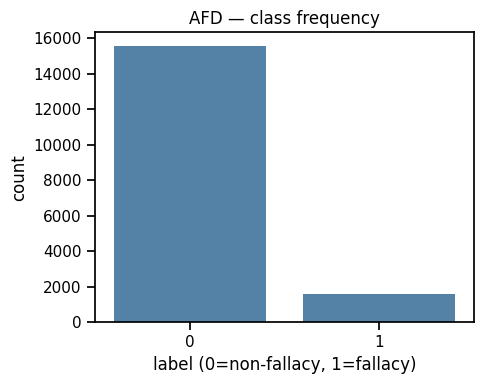

fallacy rate: 0.09159948592125249


In [4]:
# Binary label distribution
vc = df["label"].value_counts().sort_index()
display(vc.to_frame("n"))

plt.figure(figsize=(5, 4))
sns.barplot(x=vc.index.astype(str), y=vc.values, color="steelblue")
plt.xlabel("label (0=non-fallacy, 1=fallacy)")
plt.ylabel("count")
plt.title("AFD — class frequency")
plt.tight_layout()
plt.show()

print("fallacy rate:", float((df["label"] == 1).mean()))

In [5]:
df["label_name"] = df["label"].map({0: "NonFallacy", 1: "Fallacy"})

count    17118.000000
mean        16.643241
std         12.631511
min          1.000000
25%          8.000000
50%         13.000000
75%         22.000000
max        152.000000
Name: sentence_word_len, dtype: float64

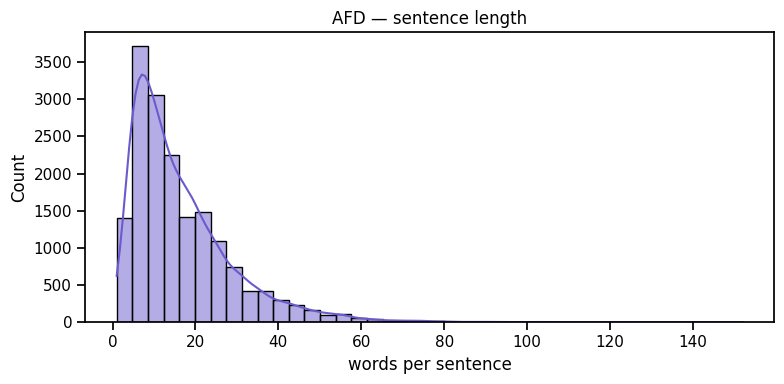

In [7]:
# Sentence length (words)
df["sentence_word_len"] = df["sentence"].astype(str).str.split().str.len()

display(df["sentence_word_len"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df["sentence_word_len"], bins=40, kde=True, color="slateblue")
plt.xlabel("words per sentence")
plt.title("AFD — sentence length")
plt.tight_layout()
plt.show()

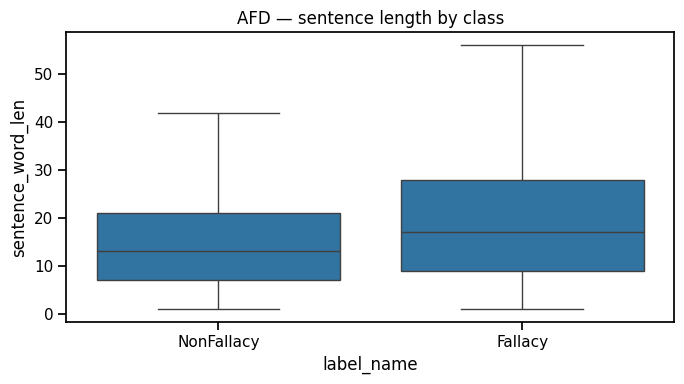

In [8]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="label_name", y="sentence_word_len", showfliers=False)
plt.title("AFD — sentence length by class")
plt.tight_layout()
plt.show()

count    17118.000000
mean        49.724325
std         24.447738
min          0.000000
25%         32.000000
50%         45.000000
75%         63.000000
max        218.000000
Name: context_word_len, dtype: float64

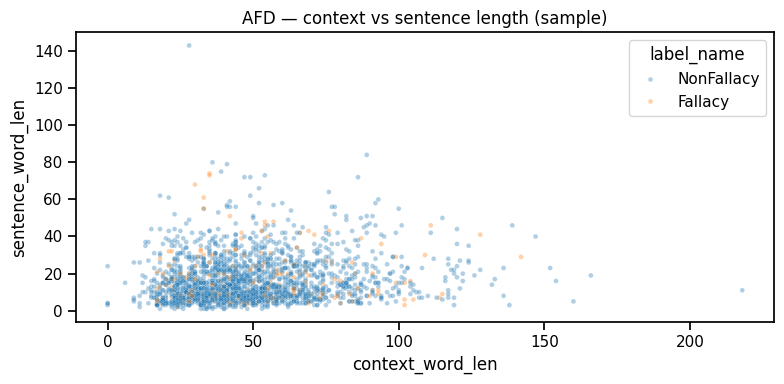

In [9]:
# Context length (words) if present
if "context" in df.columns:
    df["context_word_len"] = df["context"].astype(str).str.split().str.len()
    display(df["context_word_len"].describe())

    plt.figure(figsize=(8, 4))
    sns.scatterplot(
        data=df.sample(min(2000, len(df)), random_state=42),
        x="context_word_len",
        y="sentence_word_len",
        hue="label_name",
        alpha=0.35,
        s=12,
    )
    plt.title("AFD — context vs sentence length (sample)")
    plt.tight_layout()
    plt.show()

In [11]:
# Examples: gold Fallacy sentences (sample)
display(
    df.loc[df["label"] == 1, ["dialogue_id", "sentence"]]
    .sample(min(12, (df["label"] == 1).sum()), random_state=42)
    .reset_index(drop=True)
)

,dialogue_id,sentence
0,9_1980,It's understandable that a Senator in the prel...
1,36_2008,"In fact, what, Joe, if you want to do the righ..."
2,25_2000,You leave future generations with tremendous I...
3,36_2008,"We need to encourage business, create jobs, no..."
4,36_2008,That's what he's done when it comes to economi...
5,8_1980,We spoke a multitude of tongues.
6,6_1976,If the United States had not moved when we did...
7,33_2008,"The question is for the next president, are we..."
8,9_1980,Governor Reagan is making some very misleading...
9,28_2000,And we can renew and rekindle the American spi...


In [12]:
# Duplicate sentence text across dialogues (AFD-specific pain point)
dup = (
    df.groupby(df["sentence"].astype(str), as_index=False)
    .agg(n_dialogues=("dialogue_id", "nunique"), dialogues=("dialogue_id", lambda s: sorted(set(s))))
)
dup = dup.sort_values("n_dialogues", ascending=False)
display(dup.head(15))
print("sentences appearing in >1 dialogue:", int((dup["n_dialogues"] > 1).sum()))

/tmp/ipykernel_304045/3136078304.py:4: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .agg(n_dialogues=("dialogue_id", "nunique"), dialogues=("dialogue_id", lambda s: sorted(set(s))))


,n_dialogues,dialogues
16465,15,"[10_1984, 12_1984, 20_1992, 23_1996, 25_2000, ..."
11568,13,"[10_1984, 18_1992, 21_1992, 22_1996, 28_2000, ..."
9743,9,"[10_1984, 18_1992, 22_1996, 25_2000, 27_2000, ..."
11541,7,"[13_1988, 21_1992, 28_2000, 32_2004, 36_2008, ..."
162,6,"[21_1992, 26_2000, 27_2000, 31_2004, 36_2008, ..."
11567,5,"[26_2000, 28_2000, 29_2004, 31_2004, 9_1980]"
10385,5,"[10_1984, 18_1992, 21_1992, 25_2000, 44_2020]"
160,4,"[22_1996, 27_2000, 28_2000, 39_2012]"
4492,4,"[12_1984, 29_2004, 31_2004, 39_2012]"
11900,4,"[22_1996, 33_2008, 39_2012, 44_2020]"


sentences appearing in >1 dialogue: 86
